In [72]:
import matplotlib.pyplot as plt
from datasets import load_dataset

from autogradus.nn import MLP, cross_entropy_loss

%matplotlib inline

In [66]:
# Load MNIST dataset

ds = load_dataset("ylecun/mnist")

ds_train = ds["train"].select(range(200))
ds_test = ds["test"].select(range(200))

print(ds_train["label"][0])
ds_train["image"][0]

5


In [67]:
# Create model

classifier = MLP(784, [32, 10])

In [68]:
# Training loop

LR = 0.03
losses = []
for k in range(10):
    for c, data in enumerate(ds_train):
        x = [pixel / 255.0 for pixel in data["image"].get_flattened_data()]
        gt = data["label"]
        output = classifier(x)
        loss = cross_entropy_loss(output, gt)

        losses.append(loss.data)

        # Zero grad
        for p in classifier.parameters():
            p.grad = 0.0

        # Backprop
        loss.backward()

        # Step
        for p in classifier.parameters():
            p.data += -p.grad * LR

    if len(losses) >= 100:
        print("Step:", k, "Mean 100 loss:", sum(losses[-100:]) / 100)
    else:
        print("Step:", k, "Mean loss:", sum(losses) / len(losses))

Step: 0 Mean 100 loss: 1.3722101001609428
Step: 1 Mean 100 loss: 0.6848505211486313
Step: 2 Mean 100 loss: 0.3801751870152904
Step: 3 Mean 100 loss: 0.1956513827041225
Step: 4 Mean 100 loss: 0.10953123251062222
Step: 5 Mean 100 loss: 0.07075455152720378
Step: 6 Mean 100 loss: 0.05093194336930279
Step: 7 Mean 100 loss: 0.039523829289622545
Step: 8 Mean 100 loss: 0.032158419886211306
Step: 9 Mean 100 loss: 0.027027965560393073


In [69]:
losses

[2.481769431398503,
 2.6404465039046805,
 3.0690175319276007,
 1.435917322687286,
 3.449462979298834,
 2.565606479813192,
 1.4500803194641885,
 2.4419759945418504,
 1.2045803723176538,
 2.8886956718144736,
 1.9973657354147643,
 2.518344884996377,
 1.4135094254538905,
 3.124515713449393,
 1.3769236929594304,
 2.809258028238135,
 2.558998768243995,
 2.808126665074897,
 2.681242139854384,
 3.02752592587016,
 2.711109077262334,
 2.347680839112112,
 2.696463281863884,
 1.6341029989439224,
 1.620885556364506,
 2.3837871597007827,
 2.5726287855911485,
 1.748037658210124,
 2.096805712913141,
 2.574827860222348,
 1.8352243135209632,
 2.5557907178289128,
 2.5223949445618468,
 2.5913736455845497,
 2.5246859988013934,
 2.4996882479115325,
 2.1140431101072177,
 1.6002328626284008,
 2.6646389215164694,
 1.5872922797285298,
 1.5990803233592992,
 2.6542497391408677,
 2.4399434846631616,
 2.3983002407784375,
 1.9860206165800733,
 2.1698694385994775,
 2.2775748906020596,
 2.456855874754345,
 2.260228916

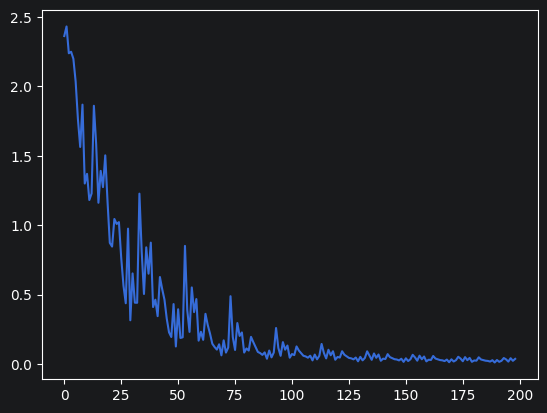

In [70]:
# Mean 10 loss curve

losses_mean_10 = []
for i in range(0, len(losses) - 10, 10):
    losses_mean_10.append(sum(losses[i:i + 10]) / 10)
plt.plot(losses_mean_10)

In [71]:
# Test accuracy

correct = 0
total = len(ds_test)
for data in ds_test:
    x = [pixel / 255.0 for pixel in data["image"].get_flattened_data()]
    gt = data["label"]
    output = classifier(x)
    pred = max(range(len(output)), key=lambda i: output[i].data)
    correct += pred == gt
accuracy = correct / total
print("Accuracy:", accuracy)

Accuracy: 0.725
